In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

In [ ]:

# Load the dataset
df = pd.read_csv("/content/drive/MyDrive/Students_Grading_Dataset.csv")
df.head()

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Engineering,52.29,55.03,57.82,...,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
1,S1001,Maria,Brown,student1@university.com,Male,18,Engineering,97.27,97.23,45.80,...,55.65,50.64,A,19.0,No,Yes,NaN,Medium,4,9.0
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Business,57.19,67.05,93.68,...,73.79,70.30,D,20.7,No,Yes,Master's,Low,6,6.2
3,S1003,Omar,Williams,student3@university.com,Female,24,Mathematics,95.15,47.79,80.63,...,92.12,61.63,A,24.8,Yes,Yes,High School,High,3,6.7
4,S1004,John,Smith,student4@university.com,Female,23,CS,54.18,46.59,78.89,...,68.42,66.13,F,15.4,Yes,Yes,High School,High,2,7.1


In [ ]:
# prompt: count rows

import pandas as pd
from scipy.stats import mannwhitneyu

# Load the dataset
df = pd.read_csv("/content/drive/MyDrive/Students_Grading_Dataset.csv")

# Count the number of rows
num_rows = len(df)
print(f"The number of rows in the DataFrame is: {num_rows}")


The number of rows in the DataFrame is: 5000


In [ ]:
# Check and print the number of students with and without internet access
count = df['Internet_Access_at_Home'].value_counts()
print(count)

Internet_Access_at_Home
Yes    4485
No      515
Name: count, dtype: int64


In [ ]:

# Select relevant columns and drop missing values
df_test1 = df[['Internet_Access_at_Home', 'Total_Score']].dropna()
df_test1.head()

,Internet_Access_at_Home,Total_Score
0,Yes,56.09
1,Yes,50.64
2,Yes,70.30
3,Yes,61.63
4,Yes,66.13


In [ ]:

# Randomly sample 25 students with and without internet access
with_internet = df_test1[df_test1['Internet_Access_at_Home'] == 'Yes'].sample(25, random_state=1)
without_internet = df_test1[df_test1['Internet_Access_at_Home'] == 'No'].sample(25, random_state=0)
sample_df = pd.concat([with_internet, without_internet])
sample_df.head()

,Internet_Access_at_Home,Total_Score
2075,Yes,82.79
2551,Yes,81.07
2193,Yes,83.01
3194,Yes,50.49
4801,Yes,90.23


In [ ]:
# prompt: check this data is normally distributed or not

import pandas as pd
from scipy.stats import shapiro, normaltest

# Load the dataset (assuming it's already loaded as 'df' from previous code)
# If not, uncomment the line below and replace with correct path
# df = pd.read_csv("/content/drive/MyDrive/Students_Grading_Dataset.csv")

# Select the 'Total_Score' column
total_scores = df['Total_Score']

# Shapiro-Wilk Test
shapiro_test = shapiro(total_scores)
print("Shapiro-Wilk Test:")
print(f"Statistic: {shapiro_test.statistic}")
print(f"P-value: {shapiro_test.pvalue}")

# D’Agostino’s K^2 Test
k2_test = normaltest(total_scores)
print("\nD'Agostino's K^2 Test:")
print(f"Statistic: {k2_test.statistic}")
print(f"P-value: {k2_test.pvalue}")

# Interpretation
alpha = 0.05  # Significance level
print("\nInterpretation:")
if shapiro_test.pvalue > alpha:
    print("Shapiro-Wilk test: Data is likely normally distributed.")
else:
    print("Shapiro-Wilk test: Data is likely not normally distributed.")

if k2_test.pvalue > alpha:
    print("D'Agostino's K^2 test: Data is likely normally distributed.")
else:
    print("D'Agostino's K^2 test: Data is likely not normally distributed.")


Shapiro-Wilk Test:
Statistic: 0.9557300977233065
P-value: 1.7372450365530298e-36

D'Agostino's K^2 Test:
Statistic: 4000.9167866341136
P-value: 0.0

Interpretation:
Shapiro-Wilk test: Data is likely not normally distributed.
D'Agostino's K^2 test: Data is likely not normally distributed.


In [ ]:
# Perform the Mann–Whitney U Test
statistic, p_value = mannwhitneyu(
    with_internet['Total_Score'],
    without_internet['Total_Score'],
    alternative='two-sided'
)


In [ ]:
# Calculate mean scores for reference
mean_with_internet = with_internet['Total_Score'].mean()
mean_without_internet = without_internet['Total_Score'].mean()


In [ ]:

# Print results
print("Mann–Whitney U Test Results")

print(f"U Statistic: {statistic}")
print(f"p-value: {p_value}")
print(f"Mean Total Score (Internet Access): {mean_with_internet:.2f}")
print(f"Mean Total Score (No Internet Access): {mean_without_internet:.2f}")

Mann–Whitney U Test Results
U Statistic: 288.0
p-value: 0.6414528745894932
Mean Total Score (Internet Access): 74.80
Mean Total Score (No Internet Access): 76.10


In [ ]:

# Conclusion
if p_value < 0.05:
    print("Conclusion: Reject the null hypothesis – significant difference found.")
else:
    print("Conclusion: Fail to reject the null hypothesis – no significant difference found.")

Conclusion: Fail to reject the null hypothesis – no significant difference found.


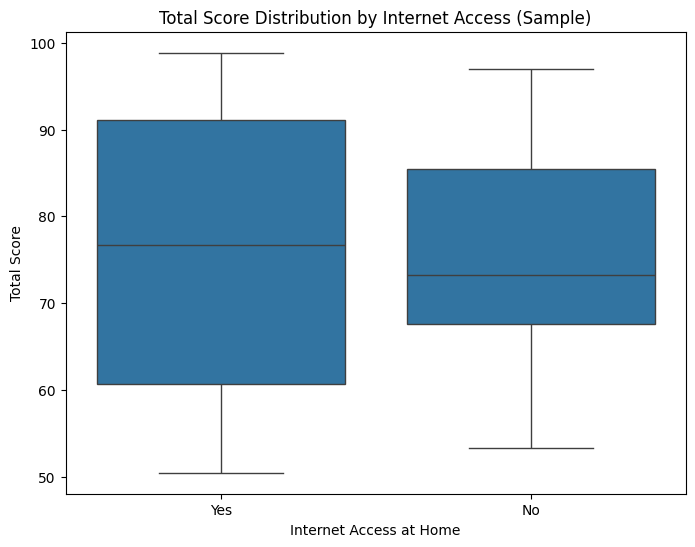

In [ ]:
# prompt: create suitable box  plot for using this result and compare sample result

import matplotlib.pyplot as plt
import seaborn as sns

# Create the box plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Internet_Access_at_Home', y='Total_Score', data=sample_df)
plt.title('Total Score Distribution by Internet Access (Sample)')
plt.xlabel('Internet Access at Home')
plt.ylabel('Total Score')
plt.show()



<ipython-input-14-027610f23ba3>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Access', y='Total_Score', palette='Set2')


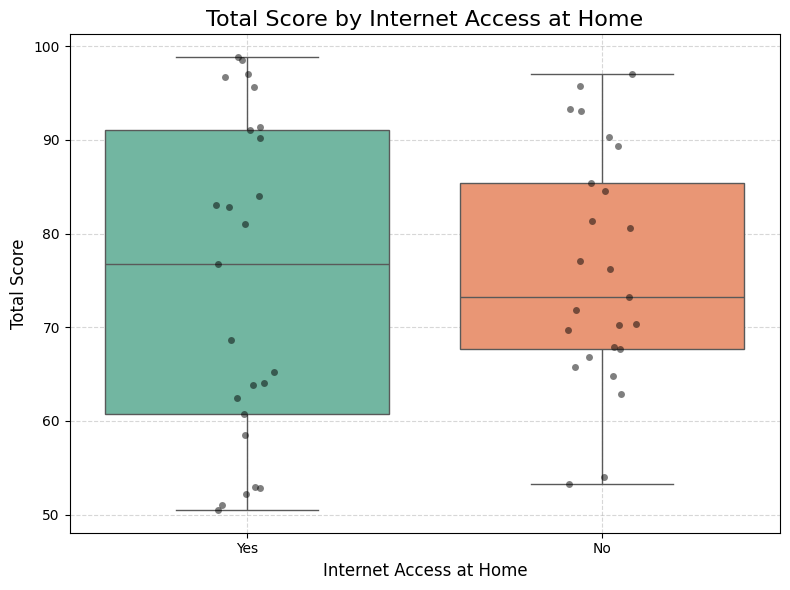

In [ ]:
# prompt: create box plot for explain that result

# Combine the two groups into one DataFrame for plotting
with_internet['Access'] = 'Yes'
without_internet['Access'] = 'No'
plot_df = pd.concat([with_internet, without_internet])

# Set up the plot
plt.figure(figsize=(8, 6))
sns.boxplot(data=plot_df, x='Access', y='Total_Score', palette='Set2')

# Add mean points
sns.stripplot(data=plot_df, x='Access', y='Total_Score',
              color='black', size=5, jitter=True, alpha=0.5)

# Titles and labels
plt.title('Total Score by Internet Access at Home', fontsize=16)
plt.xlabel('Internet Access at Home', fontsize=12)
plt.ylabel('Total Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Show the plot
plt.tight_layout()
plt.show()
